# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [81]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [82]:
## DONE : load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
#Loaded from other link
file_1 ='Churn_Modelling.csv'

In [83]:
## DONE : make into a dataframe called df
df = pd.read_csv(file_1)

In [84]:
## DONE : output the first 5 lines
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [85]:
## DONE : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively
df_0 = df[df['Exited']==0]
df_1 = df[df['Exited']==1]

## Hypothesis 1: Age

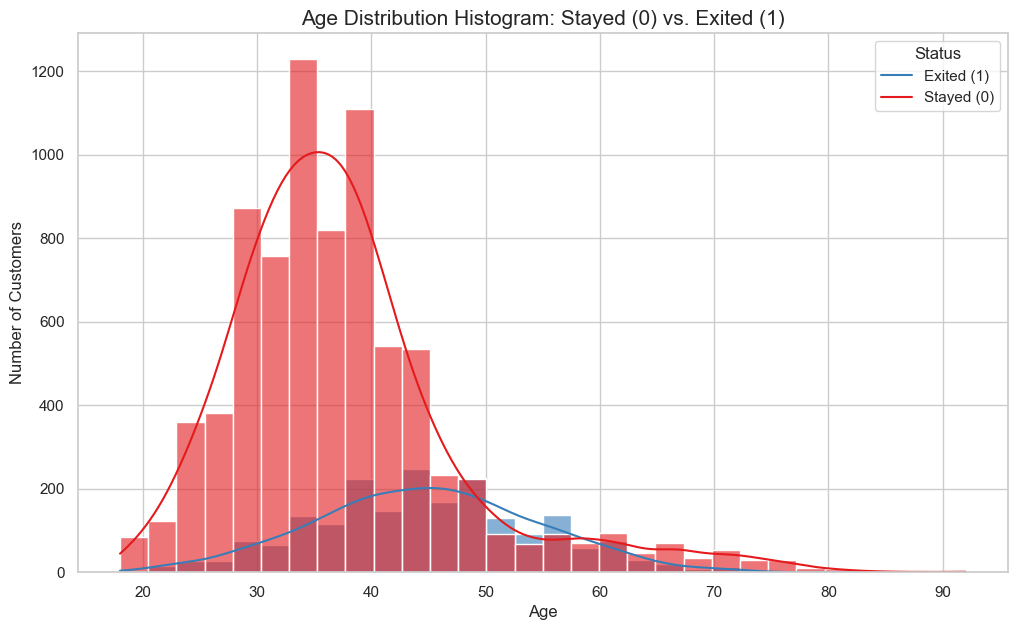

In [86]:
## DONE: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.
# Set visual style and context for clarity
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

# 1. Plotting the histogram
# element="step" or "bars" with multiple="layer" creates the most readable overlap
sns.histplot(
    data=df, 
    x='Age', 
    hue='Exited', 
    bins=30,           # Adjust number of bins for more/less detail
    palette='Set1',    # High-contrast categorical palette (Red vs Blue)
    kde=True,          # Keep the line for trend visualization
    alpha=0.6,         # Transparency to see overlapping bars
    element="bars",    # Classic histogram bars
    common_norm=False  # Normalizes height relative to each group's size
)

# 2. Add labeling
plt.title('Age Distribution Histogram: Stayed (0) vs. Exited (1)', fontsize=15)
plt.xlabel('Age')
plt.ylabel('Number of Customers')

# 3. Explicitly fix the legend labels
plt.legend(title='Status', labels=['Exited (1)', 'Stayed (0)'])

plt.show()

In [87]:
## DONE: Calculate the mean and standard deviation of the age for customers who stayed with the bank.
print(f"""For customers who stayed with the bank:
      Mean: {df_0['Age'].mean():4f}
      Std. Dev.: {df_0['Age'].std():4f}""")

For customers who stayed with the bank:
      Mean: 37.408389
      Std. Dev.: 10.125363


In [88]:
## DONE: Calculate the mean and standard deviation of the age for customers who left the bank.
print(f"""For customers who left the bank:
Mean: {df_1['Age'].mean():4f}
Std. Dev.: {df_1['Age'].std():4f}""")

For customers who left the bank:
Mean: 44.837997
Std. Dev.: 9.761562


In [89]:
## DONE: Perform a t-test to compare the ages of customers who stayed and left the bank.
from scipy.stats import ttest_ind
t_stat_age, p_val_t_age = ttest_ind(df_0['Age'], df_1['Age'])
print(f"""T-Test Results:
T Statistic: {t_stat_age:4f}
P Value: {p_val_t_age:4f}""")

T-Test Results:
T Statistic: -29.766815
P Value: 0.000000


In [90]:
print('Conclusion: The ages of people who left the bank and who did not are not similar to a significant degree.')

Conclusion: The ages of people who left the bank and who did not are not similar to a significant degree.


### Using Bootstrapping

In [91]:
# ## DONE: Write a function to perform bootstrap sampling and calculate the statistic of interest.
# def bs_choice(data, func, size):
#     bs_s =
#     for i in range(size):
#         bs_abc =
#         bs_s[i] = func(bs_abc)
#     return bs_s

def bs_choice(data, func, size):
    """
    Performs bootstrap sampling and calculates a statistic.
    
    Parameters:
    data: The original 1D array/Series of data.
    func: The statistic function (e.g., np.mean, np.median).
    size: The number of bootstrap replicates to create.
    """
    # Initialize an array of zeros to store the replicates
    bs_s = np.empty(size)
    
    for i in range(size):
        # Generate a bootstrap sample (same length as data, with replacement)
        bs_abc = np.random.choice(data, size=len(data), replace=True)
        
        # Calculate the statistic and store it
        bs_s[i] = func(bs_abc)
        
    return bs_s

In [92]:
## DONE: Calculate the difference in means and shift the ages to the overall mean.
# Calculate the observed difference in means
obs_diff = np.mean(df_1['Age']) - np.mean(df_0['Age'])

print(f"Observed difference in mean age: {obs_diff:.4f}")
# Calculate the mean of all ages combined
overall_mean = np.mean(df['Age'])

# Shift the ages so that the mean of each group is the overall_mean
df_0_shifted = df_0['Age'] - np.mean(df_0['Age']) + overall_mean
df_1_shifted = df_1['Age'] - np.mean(df_1['Age']) + overall_mean

Observed difference in mean age: 7.4296


In [93]:
## DONE: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.

# 1. Generate bootstrap replicates for standard deviation
# We use np.std as the 'func' argument
size = 10000

# Replicates for Group 0 (Stayed)
bs_std_0 = bs_choice(df_0['Age'], np.std, size)

# Replicates for Group 1 (Exited)
bs_std_1 = bs_choice(df_1['Age'], np.std, size)

# 2. Calculate the difference in standard deviations
# (Group 1 - Group 0)
bs_std_diff = bs_std_1 - bs_std_0

# 3. Calculate 95% Confidence Intervals for the difference
ci_low, ci_high = np.percentile(bs_std_diff, [2.5, 97.5])
print(f'Std. Dev. for Group 0 (Stayed): {np.mean(bs_std_0):.4f}')
print(f'Std. Dev. for Group 1 (Left): {np.mean(bs_std_1):.4f}')
print(f'Difference in Std. Devs.: {np.mean(bs_std_diff):.4f}')
print(f"95% CI for the difference in Standard Deviations: [{ci_low:.4f}, {ci_high:.4f}]")

Std. Dev. for Group 0 (Stayed): 10.1261
Std. Dev. for Group 1 (Left): 9.7580
Difference in Std. Devs.: -0.3681
95% CI for the difference in Standard Deviations: [-0.7515, 0.0176]


In [94]:
## DONE: Calculate the p-value by comparing the difference in means to the bootstrap distribution.
# 1. Generate bootstrap replicates of the mean for the SHIFTED data
# Using the bs_choice function defined earlier
size = 10000

bs_replicates_0 = bs_choice(df_0_shifted, np.mean, size)
bs_replicates_1 = bs_choice(df_1_shifted, np.mean, size)

# 2. Get the distribution of the differences under the null hypothesis
bs_diff_replicates = bs_replicates_1 - bs_replicates_0

# 3. Calculate the p-value
# We count how many bootstrap differences are greater than or equal to the observed difference
p_value = np.sum(bs_diff_replicates >= obs_diff) / len(bs_diff_replicates)

print(f"Observed Difference: {obs_diff:.4f}")
print(f"P-value: {p_value:.5f}")

Observed Difference: 7.4296
P-value: 0.00000


### Conclusion
Do we reject the Null Hypothesis ? Why ?

Yes, we reject the Null Hypothesis--and conclude the ages of those who left the bank and those who stayed are significantly different--because we receive a very low p-value, of 0.00, through both a T-Test and by comparing the difference in means to the bootstrap distribution.

## Hypothesis 2: Credit Score

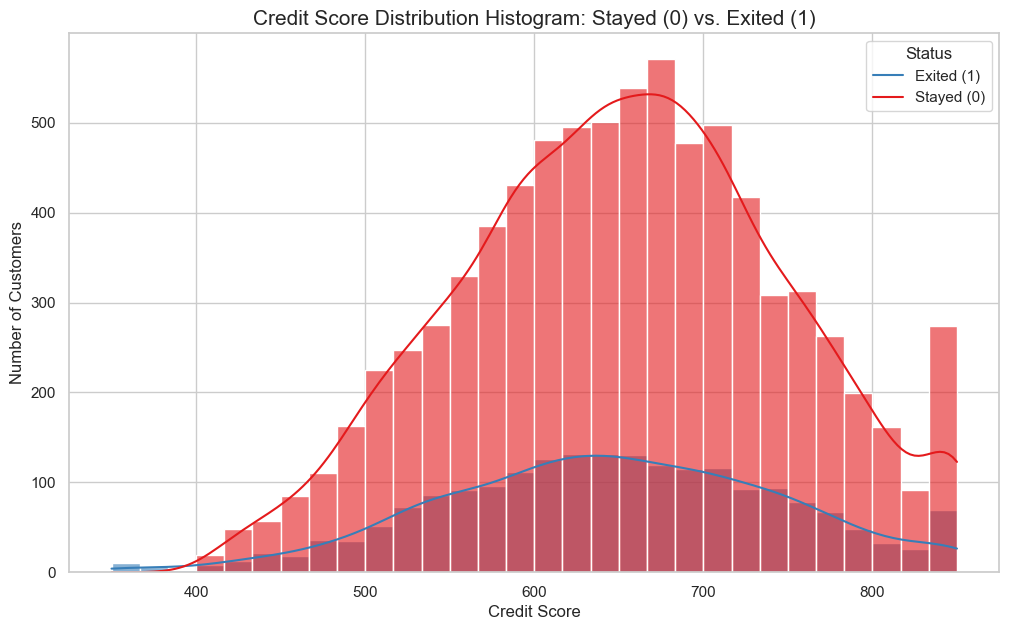

In [95]:
## DONE: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).
# Set the style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

# 1. Plotting the histogram
# element="step" or "bars" with multiple="layer" creates the most readable overlap
sns.histplot(
    data=df, 
    x='CreditScore', 
    hue='Exited', 
    bins=30,           # Adjust number of bins for more/less detail
    palette='Set1',    # High-contrast categorical palette (Red vs Blue)
    kde=True,          # Keep the line for trend visualization
    alpha=0.6,         # Transparency to see overlapping bars
    element="bars",    # Classic histogram bars
    common_norm=False  # Normalizes height relative to each group's size
)

# 2. Add labeling
plt.title('Credit Score Distribution Histogram: Stayed (0) vs. Exited (1)', fontsize=15)
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')

# 3. Explicitly fix the legend labels
plt.legend(title='Status', labels=['Exited (1)', 'Stayed (0)'])

plt.show()

In [96]:
## DONE: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).
t_stat_credit, p_val_t_credit = ttest_ind(df_0['CreditScore'], df_1['CreditScore'])
print(f"""T-Test Results:
T Statistic: {t_stat_credit:4f}
P Value: {p_val_t_credit:4f}""")

T-Test Results:
T Statistic: 2.710078
P Value: 0.006738


### Conclusion
Do we reject the Null Hypothesis ? Why ?
Yes, we reject the Null Hypothesis (and conclude the Credit Scores of the two groups are not similar) because the P Value is under 0.05: it is 0.006738.

## Hypothesis 3: Balance

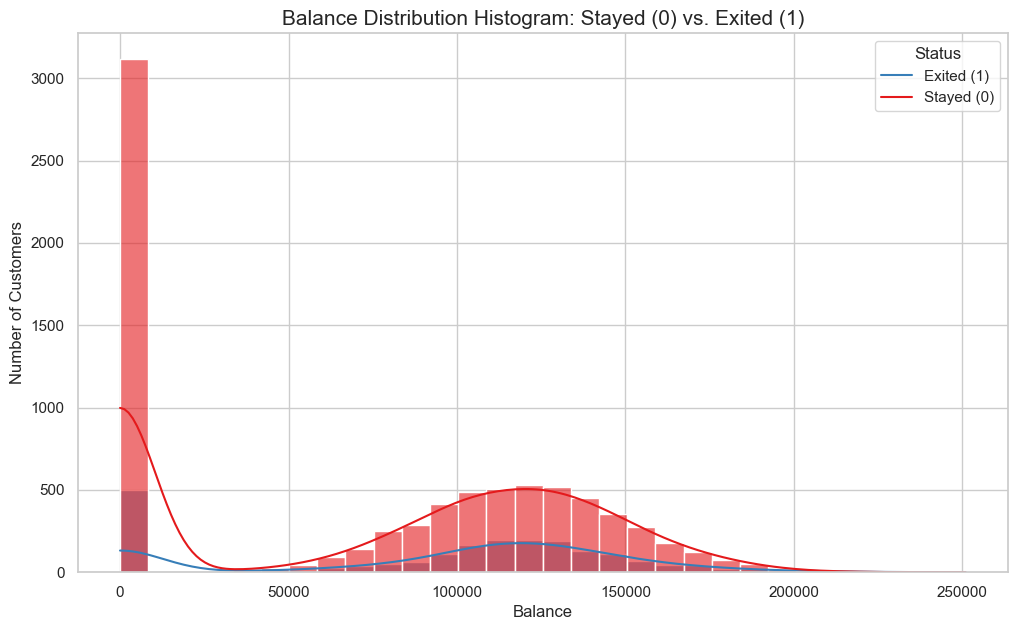

In [97]:
## DONE: Plot the distribution of Balance for both groups (Still with bank and Left the bank).

# Set the style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

# 1. Plotting the histogram
# element="step" or "bars" with multiple="layer" creates the most readable overlap
sns.histplot(
    data=df, 
    x='Balance', 
    hue='Exited', 
    bins=30,           # Adjust number of bins for more/less detail
    palette='Set1',    # High-contrast categorical palette (Red vs Blue)
    kde=True,          # Keep the line for trend visualization
    alpha=0.6,         # Transparency to see overlapping bars
    element="bars",    # Classic histogram bars
    common_norm=False  # Normalizes height relative to each group's size
)

# 2. Add labeling
plt.title('Balance Distribution Histogram: Stayed (0) vs. Exited (1)', fontsize=15)
plt.xlabel('Balance')
plt.ylabel('Number of Customers')

# 3. Explicitly fix the legend labels
plt.legend(title='Status', labels=['Exited (1)', 'Stayed (0)'])

plt.show()

In [98]:
## DONE: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.
t_stat_balance, p_val_t_balance = ttest_ind(df_0['Balance'], df_1['Balance'])
print(f"""T-Test Results:
T Statistic: {t_stat_balance:4f}
P Value: {p_val_t_balance:4f}""")

T-Test Results:
T Statistic: -11.936240
P Value: 0.000000


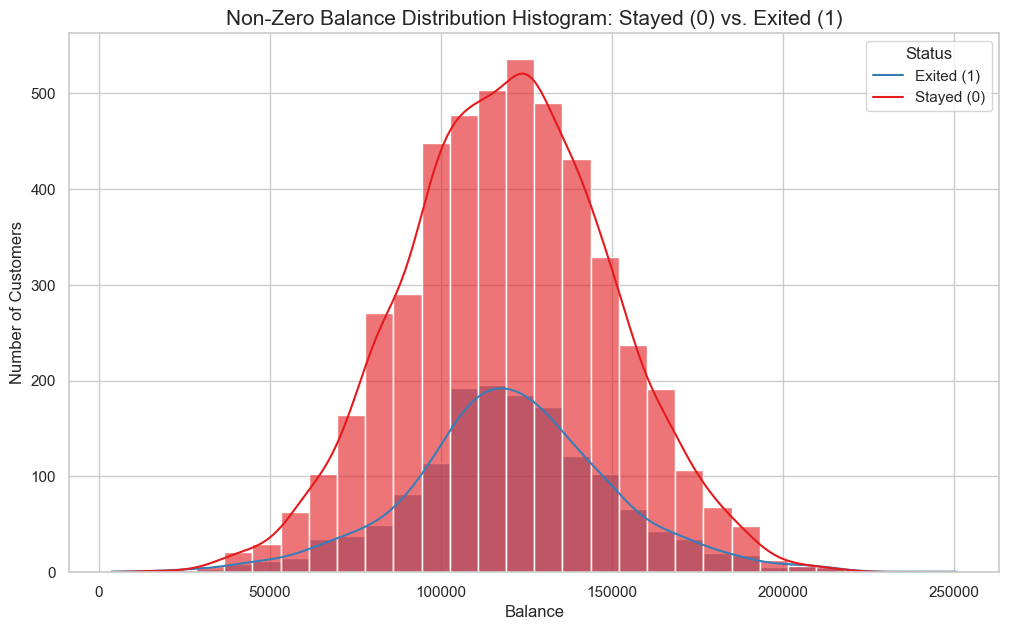

In [99]:
## DONE: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.
df_nonzero = df[df['Balance']!=0]
# Set the style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

# 1. Plotting the histogram
# element="step" or "bars" with multiple="layer" creates the most readable overlap
sns.histplot(
    data=df_nonzero, 
    x='Balance', 
    hue='Exited', 
    bins=30,           # Adjust number of bins for more/less detail
    palette='Set1',    # High-contrast categorical palette (Red vs Blue)
    kde=True,          # Keep the line for trend visualization
    alpha=0.6,         # Transparency to see overlapping bars
    element="bars",    # Classic histogram bars
    common_norm=False  # Normalizes height relative to each group's size
)

# 2. Add labeling
plt.title('Non-Zero Balance Distribution Histogram: Stayed (0) vs. Exited (1)', fontsize=15)
plt.xlabel('Balance')
plt.ylabel('Number of Customers')

# 3. Explicitly fix the legend labels
plt.legend(title='Status', labels=['Exited (1)', 'Stayed (0)'])

plt.show()


In [100]:
## DONE: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.

df_nonzero_0 = df_nonzero[df_nonzero['Exited']==0]
df_nonzero_1 = df_nonzero[df_nonzero['Exited']==1]

t_stat_nonzero_balance, p_val_t_nonzero_balance = ttest_ind(df_nonzero_0['Balance'], df_nonzero_1['Balance'])
print(f"""T-Test Results:
T Statistic: {t_stat_nonzero_balance:4f}
P Value: {p_val_t_nonzero_balance:4f}""")

T-Test Results:
T Statistic: -1.374782
P Value: 0.169247


## Conclusion

Do we reject the Null Hypothesis ? Why ?

Null Hypothesis 3 is that the balance of people who left the bank and who did not are similar.
We reject the Null Hypothesis, because a T-Test found a P Value 0.000000: The two groups had different balances.
However, if we exclude customers with zero balances, we find a P Value of 0.169247, which is above 0.05, and thus do not reject the Null Hypothesis. We find that for customers with positive balances, there was no statistically significant difference in balances between the two groups.



## Hypothesis 4: Estimated Salary

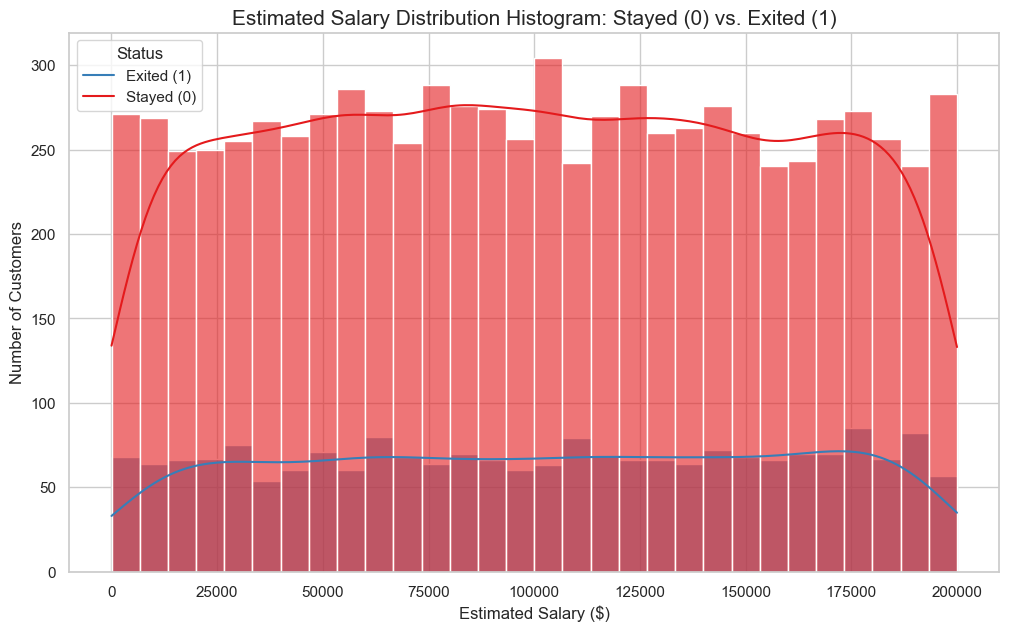

In [101]:
## DONE: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.

# Set the style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

# 1. Plotting the histogram
# element="step" or "bars" with multiple="layer" creates the most readable overlap
sns.histplot(
    data=df, 
    x='EstimatedSalary', 
    hue='Exited', 
    bins=30,           # Adjust number of bins for more/less detail
    palette='Set1',    # High-contrast categorical palette (Red vs Blue)
    kde=True,          # Keep the line for trend visualization
    alpha=0.6,         # Transparency to see overlapping bars
    element="bars",    # Classic histogram bars
    common_norm=False  # Normalizes height relative to each group's size
)

# 2. Add labeling
plt.title('Estimated Salary Distribution Histogram: Stayed (0) vs. Exited (1)', fontsize=15)
plt.xlabel('Estimated Salary ($)')
plt.ylabel('Number of Customers')

# 3. Explicitly fix the legend labels
plt.legend(title='Status', labels=['Exited (1)', 'Stayed (0)'])

plt.show()

In [102]:
## DONE: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.
t_stat_salary, p_val_t_salary = ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'])
print(f"""T-Test Results:
T Statistic: {t_stat_salary:4f}
P Value: {p_val_t_salary:4f}""")

T-Test Results:
T Statistic: -1.209654
P Value: 0.226440


### Using Bootstrapping

In [103]:
## TODO: Calculate the difference in means and shift the EstimatedSalary for both groups.
# Calculate the observed difference in means
obs_diff_sal = np.mean(df_1['EstimatedSalary']) - np.mean(df_0['EstimatedSalary'])

print(f"Observed difference in mean EstimatedSalary: {obs_diff:.4f}")
# Calculate the mean of all EstimatedSalarys combined
overall_mean_sal = np.mean(df['EstimatedSalary'])

# Shift the EstimatedSalarys so that the mean of each group is the overall_mean
df_0_shifted_sal = df_0['EstimatedSalary'] - np.mean(df_0['EstimatedSalary']) + overall_mean_sal
df_1_shifted_sal = df_1['EstimatedSalary'] - np.mean(df_1['EstimatedSalary']) + overall_mean_sal

Observed difference in mean EstimatedSalary: 7.4296


In [104]:
## TODO: Calculate the bootstrap sample means for both groups and their difference.

# 1. Generate bootstrap replicates for standard deviation
# We use np.std as the 'func' argument
size = 10000

# Replicates for Group 0 (Stayed)
bs_std_0_sal = bs_choice(df_0['EstimatedSalary'], np.std, size)

# Replicates for Group 1 (Exited)
bs_std_1_sal = bs_choice(df_1['EstimatedSalary'], np.std, size)

# 2. Calculate the difference in standard deviations
# (Group 1 - Group 0)
bs_std_diff_sal = bs_std_1_sal - bs_std_0_sal

# 3. Calculate 95% Confidence Intervals for the difference
ci_low, ci_high = np.percentile(bs_std_diff_sal, [2.5, 97.5])
print(f'Std. Dev. for Group 0 (Stayed): {np.mean(bs_std_0_sal):.4f}')
print(f'Std. Dev. for Group 1 (Left): {np.mean(bs_std_1_sal):.4f}')
print(f'Difference in Std. Devs.: {np.mean(bs_std_diff_sal):.4f}')
print(f"95% CI for the difference in Standard Deviations: [{ci_low:.4f}, {ci_high:.4f}]")

Std. Dev. for Group 0 (Stayed): 57397.5149
Std. Dev. for Group 1 (Left): 57877.3037
Difference in Std. Devs.: 479.7888
95% CI for the difference in Standard Deviations: [-792.1913, 1716.8646]


In [105]:
## TODO: Calculate the p-value based on the bootstrap distribution of the difference in means.
# 1. Generate bootstrap replicates of the mean for the SHIFTED data
# Using the bs_choice function defined earlier
size = 10000

bs_replicates_0_sal = bs_choice(df_0_shifted_sal, np.mean, size)
bs_replicates_1_sal = bs_choice(df_1_shifted_sal, np.mean, size)

# 2. Get the distribution of the differences under the null hypothesis
bs_diff_replicates_sal = bs_replicates_1_sal - bs_replicates_0_sal

# 3. Calculate the p-value
# We count how many bootstrap differences are greater than or equal to the observed difference
p_value_sal = np.sum(bs_diff_replicates_sal >= obs_diff_sal) / len(bs_diff_replicates_sal)

print(f"Observed Difference: {obs_diff_sal:.4f}")
print(f"P-value: {p_value_sal:.5f}")

Observed Difference: 1727.2858
P-value: 0.11870


### Conclusion
Do we reject the Null Hypothesis ? Why ?
Here we don't reject the Null Hypothesis. The P-value is over 0.05 for both the T-Test and the p-value based on the bootstrap distribution of the difference in means. This is evident in the histogram too. Estimated Salary of people who left the bank and who did not are not significantly different.

## Final Conclusion
What will be the most helpful feature in predicting churning?
To recall P-values of various features:
Age: P-value: 0.00000
Credit Score: P-value: 0.006738
Balance (including zero balance): P-value 0.000000

However, once accounts with zero balance were removed, P-value was over 0.05 and the two groups were not statistically different in terms of balance. We can consider that accounts with zero balance are generally dormant accounts for clients who have removed all their funds from them and stop using them, essentially having churned. Thus they shouldn't really be considered as having stayed.

In that case Age is the feature with the lowest actual P-value, so Age is the most helpul feature in predicting churning. As clients get older, they are more likely to churn, possibly because their life circumstances change.